<a href="https://colab.research.google.com/github/stefaniamartinezr/Anal-tica-de-Negocios/blob/main/Parcial1Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NaiveBayes**
**Caso de estudio**

Una entidad del sector salud desea implementar un modelo de Naive Bayes para clasificar pacientes según la presencia o ausencia de diabetes, con el fin de apoyar procesos de diagnóstico y prevención temprana.

Para este análisis se utilizará el dataset Pima Indians Diabetes Database, el cual contiene variables clínicas y demográficas de los pacientes.

Las variables empleadas en el modelo son:

Pregnancies: Número de embarazos.

Glucose: Nivel de glucosa en sangre.

BloodPressure: Presión arterial diastólica.

SkinThickness: Espesor del pliegue cutáneo.

Insulin: Nivel de insulina en sangre.

BMI: Índice de masa corporal.

DiabetesPedigreeFunction: Factor hereditario asociado a diabetes.

Age: Edad del paciente.

Outcome: Variable objetivo (0 = No Diabetes, 1 = Diabetes).**

0. se procede con la carga de las librerias de trabajo

In [ ]:
import numpy as np #libreria numerica por excelencia
import pandas as pd #Libreria para la comunicación con archivo de excel

#librerias especificas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
from sklearn.tree import export_text
from sklearn.tree import DecisionTreeClassifier

from os import setns
import seaborn as sns # herramienta prara gráficas estadisticas
from sklearn.cluster import KMeans #herramienta de clustering

1. se cargan los datos de trabajo de la base de datos Pima Indians Diabetes


In [ ]:
nxl='/content/BaseDiabetesParcial.xlsx'
# seleccionamos las variables del trabajo

XDB = pd.read_excel(nxl)

# seleccionamos las variables del trabajo
XD = XDB[['Pregnancies','Glucose','BloodPressure',
          'SkinThickness','Insulin','BMI',
          'DiabetesPedigreeFunction','Age']]
XD.head()

# variable de decisión
yd = XDB['Outcome']
yd.head()


,Outcome
0,1
1,0
2,1
3,0
4,1


2. Implementamos Modelo de Naive Bayes

In [ ]:
mnb = GaussianNB()
mnb.fit(XD, yd)   # Ajustar Variables Entrada – Salida

# Mostramos las medias de las variables
u = mnb.theta_
sigma = mnb.var_;sigma = np.sqrt(sigma)

print("'Pregnancies','Glucose','BloodPressure','SkinThickness',")
print("'Insulin','BMI','DiabetesPedigreeFunction','Age'")
print(u)

print("Las desviaciones son:")
print(sigma)

'Pregnancies','Glucose','BloodPressure','SkinThickness',
'Insulin','BMI','DiabetesPedigreeFunction','Age'
[[  3.298      109.98        68.184       19.664       68.792
   30.3042     384.23954     31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731 510.31634328  37.06716418]]
Las desviaciones son:
[[  3.01418509  26.11504769  18.04500651  14.87505361  98.76637511
    7.68216884 313.1022681   11.65598626]
 [  3.7342681   31.87997934  21.45168021  17.64669932 138.43013496
    7.24941225 372.20979342  10.94777666]]


# **Análisis de Resultados**

De acuerdo con las medias obtenidas en el modelo Naive Bayes, se observa que los pacientes con diabetes (Outcome = 1) presentan valores promedio más altos en Glucose, Insulin, BMI y Age frente al grupo sin diabetes.

La diferencia más marcada se presenta en Glucose, lo que confirma que es la variable más determinante en la clasificación del modelo. También se evidencia que los pacientes con diabetes tienen mayor BMI, lo que sugiere relación con sobrepeso u obesidad.

Además, la edad promedio es mayor en el grupo con diabetes, lo que indica que el riesgo aumenta con los años.

En conclusión, las variables que más influyen en la presencia de diabetes según el modelo son principalmente Glucose, BMI, Insulin y Age, lo cual es coherente con el comportamiento clínico de la enfermedad.

3. Se procede con la evaluación del modelo. Para la evaluación de este tipo de modelo se utiliza la matriz de confución


In [ ]:
# Predicción del modelo
ydp = mnb.predict(XD)

# Matriz de confusión
cm = confusion_matrix(yd, ydp)
print("Matriz de Confusión:")
print(cm)

# extraccion de los valores
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]
TDatos = len(yd)

# 1. Exactitud
Ex = (VP + VN) / TDatos
print("Exactitud:", Ex)

# 2. Tasa de Error: fallos del modelo
TEr = (FP + FN) / TDatos
print("Tasa de Error:", TEr)

# 3. Sensibilidad
Se = VP / (VP + FN)
print("Sensibilidad:", Se)

# 4. Especificidad
Es = VN / (VN + FP)
print("Especificidad:", Es)

# 5. Precisión
Pr = VP / (VP + FP)
print("Precisión:", Pr)

# 6. Valor Predictivo Negativo
PrN = VN / (VN + FN)
print("Predicción Negativa:", PrN)

Matriz de Confusión:
[[424  76]
 [103 165]]
Exactitud: 0.7669270833333334
Tasa de Error: 0.23307291666666666
Sensibilidad: 0.6156716417910447
Especificidad: 0.848
Precisión: 0.6846473029045643
Predicción Negativa: 0.8045540796963947


# **Evaluación del Modelo**

De acuerdo con los resultados obtenidos, el modelo Naive Bayes alcanzó una exactitud del 76,7%, lo que indica un buen desempeño general en la clasificación de pacientes con y sin diabetes.

La especificidad (84,8%) muestra que el modelo identifica correctamente a la mayoría de pacientes que no tienen diabetes, lo cual es positivo porque reduce falsos diagnósticos en personas sanas.

Sin embargo, la sensibilidad (61,6%) es más baja, lo que indica que el modelo no detecta todos los casos reales de diabetes y presenta algunos falsos negativos. Esto es importante desde el punto de vista médico, ya que no identificar a un paciente diabético puede ser riesgoso.

La precisión (68,4%) indica que cuando el modelo predice diabetes, aproximadamente el 68% de las veces acierta. Además, el valor de predicción negativa (80,5%) confirma que cuando el modelo predice que un paciente no tiene diabetes, en la mayoría de los casos es correcto.

En conclusión, el modelo presenta un buen comportamiento general, especialmente para identificar pacientes sin diabetes, aunque podría mejorar en la detección de casos positivos.

4. Evaluación con un paciente (ejemplo)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
# Paciente del reto
XDp = [[2,85,65,29,94,39.6,0.93,27]]

# Predicción
resultado = mnb.predict(XDp)
print("Predicción:", resultado)

# Interpretación
if resultado[0] == 1:
    print("El paciente tiene probabilidad de Diabetes")
else:
    print("El paciente NO tiene Diabetes")

Predicción: [0]
El paciente NO tiene Diabetes


# **Arbol de decisión**
**Caso de estudio**

Una entidad del sector salud desea implementar un modelo de Árbol de Decisión para clasificar pacientes según la presencia o ausencia de diabetes, con el fin de apoyar procesos de diagnóstico y prevención temprana.

Para este análisis se utilizará el dataset Pima Indians Diabetes Database, el cual contiene variables clínicas y demográficas de los pacientes.

Las variables empleadas en el modelo son:

Pregnancies: Número de embarazos.

Glucose: Nivel de glucosa en sangre.

BloodPressure: Presión arterial diastólica.

SkinThickness: Espesor del pliegue cutáneo.

Insulin: Nivel de insulina en sangre.

BMI: Índice de masa corporal.

DiabetesPedigreeFunction: Factor hereditario asociado a diabetes.

Age: Edad del paciente.

Outcome: Variable objetivo (0 = No Diabetes, 1 = Diabetes).

0. se procee con la carga de las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import export_text
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

1. se procede con la carga de los datos de trabajo

In [ ]:
nxl ='/content/BaseDiabetesParcial.xlsx'
XDB = pd.read_excel(nxl)

# Seleccionamos variables del modelo
XD = XDB[['Pregnancies','Glucose','BloodPressure',
          'SkinThickness','Insulin','BMI',
          'DiabetesPedigreeFunction','Age']]

# Variable objetivo
yd = XDB['Outcome']

display(XD)
display(yd)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,627.00,50
1,1,85,66,29,0,26.6,351.00,31
2,8,183,64,0,0,23.3,672.00,32
3,1,89,66,23,94,28.1,167.00,21
4,0,137,40,35,168,43.1,2288.00,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.00,63
764,2,122,70,27,0,36.8,0.34,27
765,5,121,72,23,112,26.2,245.00,30
766,1,126,60,0,0,30.1,349.00,47


,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


2. Se procede con la implementación del modelo del árbol

In [ ]:
mar = DecisionTreeClassifier(criterion='gini', max_depth=4) #modelo
mar.fit(XD, yd)


ydp = mar.predict(XD)  #Esto es lo que prónostica el modelo

#  matriz de confusión
cm = confusion_matrix(yd, ydp)
print("Matriz de Confusión:")
print(cm)

# Extracción de valores
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]

# Métricas de desempeño

# 1. Exactitud
Ex = (VP + VN) / len(XD)
print("La exactitud es:", Ex)

# 2. Sensibilidad (detección de pacientes con diabetes)
Sen = VP / (VP + FN)
print("La sensibilidad es:", Sen)

# 3. Especificidad (detección de pacientes sin diabetes)
Spe = VN / (VN + FP)
print("La especificidad es:", Spe)

# 4. Precisión
Pre = VP / (VP + FP)
print("La precisión es:", Pre)

# 5. Predicción Negativa
PreNeg = VN / (VN + FN)
print("La predicción negativa es:", PreNeg)

Matriz de Confusión:
[[459  41]
 [119 149]]
La exactitud es: 0.7916666666666666
La sensibilidad es: 0.5559701492537313
La especificidad es: 0.918
La precisión es: 0.7842105263157895
La predicción negativa es: 0.7941176470588235


# **Análisis metrica de desempeño**

Exactitud: 79.17% El modelo clasifica correctamente aproximadamente 8 de cada 10 pacientes.

Sensibilidad: 55.6% El modelo detecta solo un 55% de los pacientes con diabetes. por lo que este modelo todavía deja escapar algunos casos positivos

Especificidad: 91.8% El modelo identifica muy bien a los pacientes sin diabetes. Es fuerte detectando los negativos con diabetes

Precisión: 78.42% Cuando el modelo predice diabetes, acierta en casi el 78% de los casos.

Predicción Negativa: 79.41% Cuando predice que un paciente no tiene diabetes, suele acertar en un 79%.

3. Despliegue del Árbol de decisión

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data


vs = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age'] #titulos del arbol

dot_data = export_graphviz(mar,feature_names=vs,class_names=["No Diabetes","Diabetes"],filled=True)#azul para No Diabetes, naranja para Diabetes


graph = graph_from_dot_data(dot_data)
graph.write_png('Arbol_Diabetes.png')

True

#  **Análisis de Resultados**

El árbol de decisión muestra que la variable más importante para clasificar la diabetes es Glucose, ya que es la primera división del modelo. El punto de corte principal se da en Glucose ≤ 127.5, donde se observan 768 pacientes en total, de los cuales 500 no presentan diabetes y 268 sí la presentan. Cuando la glucosa supera ese valor, aumenta considerablemente la probabilidad de pertenecer al grupo con diabetes.

En la rama izquierda (Glucose ≤ 127.5), el árbol evalúa principalmente la Edad y el BMI. Por ejemplo, cuando Age ≤ 28.5, el nodo contiene 485 pacientes, de los cuales 391 no tienen diabetes y solo 94 sí la presentan. Además, se observan nodos puros como uno con valores (13, 0), lo que significa que el 100% de esos pacientes no tienen diabetes (gini = 0). Esto representa una regla clara donde el modelo clasifica con total seguridad.

En la rama derecha (Glucose > 127.5), el modelo utiliza variables como BMI, Insulin y nuevamente Glucose. Por ejemplo, cuando Glucose ≤ 157.5 dentro de esta rama, el nodo contiene 207 pacientes con una distribución de (57, 150), donde la mayoría ya pertenece al grupo con diabetes. También aparece un nodo muy fuerte con valores (10, 79), lo que indica una altísima concentración de pacientes con diabetes en esa combinación de condiciones. Asimismo, se observan nodos puros como (0, 39), donde todos los pacientes presentan diabetes, confirmando que el modelo encuentra patrones con ciertos perfiles.

Los nodos extremos, que aunque no son completamente puros, muestran una gran concentración de pacientes en una sola categoría. Por ejemplo, el nodo de la derecha con los valores (10,79) significa que de los 89 pacientes, 79 presentan diabetes, lo que equivale aproximadamente a una probabilidad del 89% de diabetes para los pacientes que cumplen las condiciones.

En el otro extremo, aparece otro nodo con valores (149,2) que representa, que de los 151 pacientes, 149 no presentan diabetes y solo 2 sí, lo que indica una probabilidad superior al 98% de no padecer diabetes.

En conclusión, el árbol es coherente ya que: los niveles altos de glucosa, combinados con BMI elevado y ciertos niveles de insulina, aumentan significativamente la probabilidad de diabetes. Por el contrario, pacientes jóvenes con glucosa baja y BMI moderado tienden a clasificarse como no diabéticos.

4. Aquí se muestra la predicción de diabetes para una nueva tabla de datos

In [ ]:
X2DB = pd.read_excel(nxl)

X2 = X2DB[['Pregnancies','Glucose','BloodPressure',
           'SkinThickness','Insulin','BMI',
           'DiabetesPedigreeFunction','Age']]

# Aqui se Predice con el modelo entrenado
pred_hoja2 = mar.predict(X2)

# Agregar tabla
X2DB["Prediccion_Diabetes"] = pred_hoja2

display(X2DB)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Prediccion_Diabetes
0,6,148,72,35,0,33.6,627.00,50,1,1
1,1,85,66,29,0,26.6,351.00,31,0,0
2,8,183,64,0,0,23.3,672.00,32,1,1
3,1,89,66,23,94,28.1,167.00,21,0,0
4,0,137,40,35,168,43.1,2288.00,33,1,1
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.00,63,0,0
764,2,122,70,27,0,36.8,0.34,27,0,0
765,5,121,72,23,112,26.2,245.00,30,0,0
766,1,126,60,0,0,30.1,349.00,47,1,0


In [ ]:
vs = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
      'Insulin','BMI','DiabetesPedigreeFunction','Age']
tree_rules = export_text(mar, feature_names=vs)
print(tree_rules)

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- BloodPressure <= 99.00
|   |   |   |   |--- class: 1
|   |   |   |--- BloodPressure >  99.00
|   |   |   |   |--- class: 0
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- Glucose <= 99.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  99.50
|   |   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- Insulin <= 132.50
|   |   |   |   |--- class: 0
|   |   |   |--- Insulin >  132.50
|   |   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- Age <= 25.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  25

5. Evaluación con un paciente (ejemplo)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
XDp = [[2,85,65,29,94,39.6,0.93,27]]

# Predicción con el árbol
resultado_arbol = mar.predict(XDp)

print("Predicción Árbol:", resultado_arbol)

if resultado_arbol[0] == 1:
    print("El paciente tiene probabilidad de Diabetes")
else:
    print("El paciente NO tiene Diabetes")

Predicción Árbol: [0]
El paciente NO tiene Diabetes


**K-MEANS**
#**Caso de estudio**
Una entidad del sector salud desea implementar un modelo de Clusterización K-Means con el fin de identificar perfiles de pacientes según sus características clínicas y determinar qué grupos presentan mayor probabilidad de diabetes.

Para este proceso se utilizarán las siguientes variables clínicas:

Pregnancies: número de embarazos que ha tenido la paciente.

Glucose: nivel de glucosa en sangre.

BloodPressure: presión arterial.

SkinThickness: grosor del pliegue cutáneo.

Insulin: nivel de insulina.

BMI: índice de masa corporal.

DiabetesPedigreeFunction: función hereditaria de diabetes.

Age: edad del paciente.

0. se procede con la carga de las librerias de trabajo

In [ ]:
from os import setns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # herramienta prara gráficas estadisticas
from sklearn.cluster import KMeans #herramienta de clustering

1. se cargan los datos de trabajo

<Axes: >

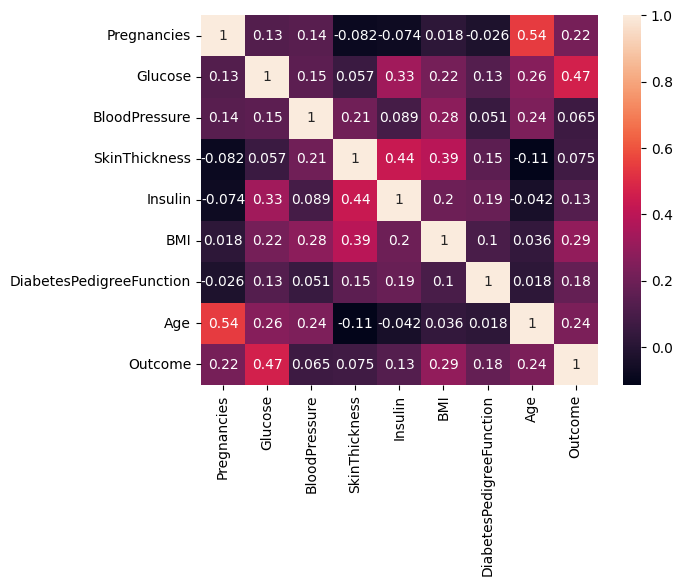

In [ ]:
# 1. se cargan los datos de trabajo

nxl='/content/BaseDiabetesParcial.xlsx'#carga de datos
XDB = pd.read_excel(nxl)

# Variable objetivo (Outcome)
yd = XDB.iloc[:,8]

# Variables de entrada (IMPORTANTE para K-Means)
XD = XDB.iloc[:,[0,1,2,3,4,5,6,7]]

# Variables para correlación
XDB2 = XDB.iloc[:,[0,1,2,3,4,5,6,7,8]]

# Heatmap, determina variables importantes
sns.heatmap(XDB2.corr(), annot=True)


# **Análisis de Resultado**

En el heatmap se observa que la relación más fuerte entre variables es Age y Pregnancies (0.54). Esto a que mayor edad, mayor número de embarazos.

También se destaca la relación entre SkinThickness e Insulin (0.44), lo que indica que cuando aumentan los niveles de insulina, también suele aumentar el grosor del pliegue cutáneo.

La variable más importante, Outcome (diabetes), ya que la mayor correlación se presenta con Glucose (0.47). Esto significa que la glucosa es la variable que más se asocia con la presencia de diabetes, lo cual tiene sentido clínicamente.

El BMI (0.29), que muestra una relación moderada. Es decir, el índice de masa corporal también influye, pero no tanto como lo es la glucosa.

Age (0.24) y Pregnancies (0.22) tienen una relación más baja con la diabetes. Influyen, pero no son factores determinantes principales.

En conclusión, la variable que más explica la presencia de diabetes en este dataset es Glucose, seguida por BMI, mientras que las demás variables no tienen tanta influencia.

cercano 1: correlación fuerte positiva
cercano 0: casi no hay relación
cercano -1: correlación fuerte negativa

2. se procede con la implemetancion del modelo K-means

In [ ]:
# Fijamos semilla
np.random.seed(42)

# Número de clusters
NC = 5   # 5 grupos (segmentos)

# Creamos el modelo
mkm = KMeans(n_clusters=NC, random_state=42)

# Ajustamos el modelo con las variables de entrada
mkm.fit(XD)

# Centros de cada cluster (perfil promedio de cada grupo)
Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
display(Tabla)

# Número de datos por cluster
ydp = mkm.labels_
NDc = np.bincount(ydp)
print("El número de datos por cluster es:", NDc)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.135417,124.041667,69.593750,23.395833,93.843750,33.420833,901.645833,35.500000
1,4.403614,117.945783,66.186747,17.879518,63.204819,31.269277,78.503313,33.819277
2,3.440000,135.760000,72.600000,24.680000,112.200000,32.492000,1517.800000,33.480000
3,3.538462,118.297659,70.615385,18.903010,53.658863,31.275585,293.234114,32.675585
4,3.741758,124.148352,68.549451,23.565934,126.021978,33.008242,569.631868,32.417582


El número de datos por cluster es: [ 96 166  25 299 182]


3. Porcentajes con Diabetes

In [ ]:
# Agregar columna Cluster
XDB2['Cluster'] = ydp
display(XDB2)

# Determinar número de pacientes con diabetes (1) y sin diabetes (0) por cluster
NDiab = XDB2.groupby('Cluster').agg({'Outcome': lambda x: (x==1).sum()})
NNoDiab = XDB2.groupby('Cluster').agg({'Outcome': lambda x: (x==0).sum()})

# Unimos los resultados
df2 = pd.DataFrame(np.column_stack((NDiab, NNoDiab)),
                   columns=['Diabetes','NoDiabetes'])

# porcentaje
NDiab2 = NDiab/(NDiab + NNoDiab)
NNoDiab2 = NNoDiab/(NDiab + NNoDiab)

df2 = pd.DataFrame(np.column_stack((NDiab2, NNoDiab2)),
                   columns=['%Diabetes','%NoDiabetes'])

display(df2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,627.00,50,1,4
1,1,85,66,29,0,26.6,351.00,31,0,3
2,8,183,64,0,0,23.3,672.00,32,1,4
3,1,89,66,23,94,28.1,167.00,21,0,1
4,0,137,40,35,168,43.1,2288.00,33,1,2
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.00,63,0,1
764,2,122,70,27,0,36.8,0.34,27,0,1
765,5,121,72,23,112,26.2,245.00,30,0,3
766,1,126,60,0,0,30.1,349.00,47,1,3


,%Diabetes,%NoDiabetes
0,0.510417,0.489583
1,0.253012,0.746988
2,0.600000,0.400000
3,0.307692,0.692308
4,0.384615,0.615385


Se puede observar que el Cluster 2 presenta la mayor probabilidad de diabetes con un 60%, seguido del Cluster 0 con aproximadamente 51%, lo que indica que estos grupos concentran el mayor riesgo de presentar la enfermedad.

Por otro lado, el Cluster 1 muestra la menor probabilidad de diabetes con solo 25%, lo que sugiere que los pacientes que pertenecen a este grupo tienen un perfil de menor riesgo. por ultimo, los clusters 3 y 4 presentan probabilidades intermedias de 30% y 38% respectivamente.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Nuevo paciente
nuevo_paciente = np.array([2,140,70,30,85,32,0.5,30]) #paciente

# Predecimos el cluster
cluster_pred = mkm.predict(nuevo_paciente.reshape(1,-1))

NCL = cluster_pred[0]
print("El nuevo paciente pertenece al cluster:", NCL)
print("La probabilidad de Diabetes para este paciente es:",round(df2.iloc[NCL,0]*100,2), "%")
print("La probabilidad de No Diabetes para este paciente es:",round(df2.iloc[NCL,1]*100,2), "%")

El nuevo paciente pertenece al cluster: 1
La probabilidad de Diabetes para este paciente es: 25.3 %
La probabilidad de No Diabetes para este paciente es: 74.7 %


4. se procede con la gráfica de los clusters utilizando las variables Ingresos, Egresos

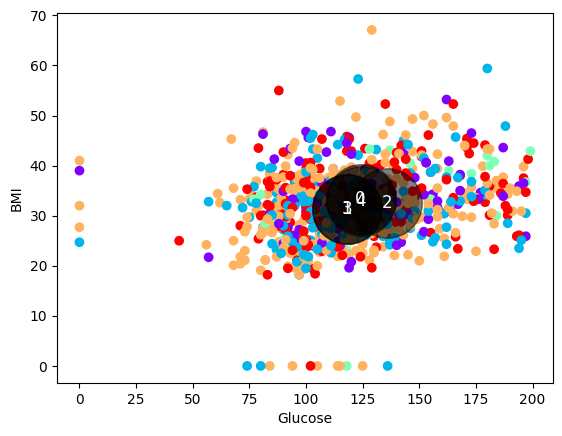

In [ ]:
centers = mkm.cluster_centers_ #centroides, Perfil o segmento

# variables para graficar
glu = np.array(XD.iloc[:,1])   # Glucose
bmi = np.array(XD.iloc[:,5])   # BMI

plt.figure()
plt.scatter(glu, bmi, c=mkm.labels_, cmap='rainbow')  # puntos de los pacientes
plt.scatter(centers[:,1], centers[:,5], c='black', s=2500, alpha=0.5) #centroides
plt.xlabel("Glucose")
plt.ylabel("BMI")

# poner los números a los clusters correspondientes
for i, center in enumerate(centers):
    plt.text(center[1], center[5], str(i), color='white', fontsize=12,ha='center', va='center')

plt.show()

En el  Cluster 0 se agrupan 96 pacientes y presenta valores promedio de aproximadamente 124 de glucosa, 33.4 de BMI y 35.5 años de edad, lo que representa un perfil intermedio dentro del conjunto de datos (no representa el menor o mayor riesgo)

El Cluster 1, que contiene 166 pacientes, presenta valores promedio de 117.9 de glucosa, 31.2 de BMI y 33.8 años de edad, lo que sugiere un perfil de pacientes con niveles de glucosa más bajos.

El Cluster 2 agrupa 25 pacientes, donde se presenta  135.7 de glucosa, sienson los niveles de promedio más altos y tambien se ven valores relativamente elevados de la insulina (112.2), lo que indica que este es un grupo con mayor riesgo potencial de diabetes.

En el Cluster 3 se encuentra el grupo más grande con 299 pacientes, caracterizado por valores promedio de 118.3 de glucosa, 31.2 de BMI y 32.6 años de edad, lo que indica que este grupo presenta valores cercanos al promedio de pacientes de la base de datos.

Finalmente, en el Cluster 4 agrupa 182 pacientes con niveles promedio de 124.1 de glucosa, 33 de BMI y 32.4 años de edad, lo que muestra características similares al cluster 0, pero con niveles de insulina más altos que el promedio.


No se ve graficamente bonito, porque no es lineal como el de PreAprobados y
PreNegados


5. Evaluación con un paciente (ejemplo)

In [ ]:
XDp = [[2,85,65,29,94,39.6,0.93,27]]

# Predicción del cluster
cluster_pred = mkm.predict(XDp)

print("El paciente pertenece al cluster:", cluster_pred[0])

# Probabilidades de ese cluster
prob_diabetes = df2.iloc[cluster_pred[0],0]*100 # porcentaje
prob_no_diabetes = df2.iloc[cluster_pred[0],1]*100

print("Probabilidad de Diabetes:", round(prob_diabetes,2), "%")
print("Probabilidad de No Diabetes:", round(prob_no_diabetes,2), "%")

El paciente pertenece al cluster: 1
Probabilidad de Diabetes: 25.3 %
Probabilidad de No Diabetes: 74.7 %
